In [1]:
from dataset_loaders import build_data_loaders
from utils.checkpoints import load_ae_from_path
from pathlib import Path
import torch

from utils.config import DatasetConfig
from visualisation import show

In [2]:
ae_path = Path("../checkpoints/autoencoder/flowers.pt")
ae = load_ae_from_path(ae_path)


In [3]:
dataset_cfg = DatasetConfig(
    name="flowers102",
    channels=3,
    height=128,
    width=128,
    num_classes=102,
    num_workers=1
)

dataloader, _ = build_data_loaders(dataset_cfg, batch_size=64)


In [4]:
images, labels = next(iter(dataloader))

with torch.no_grad():
    recon, mu, logvar = ae(images)


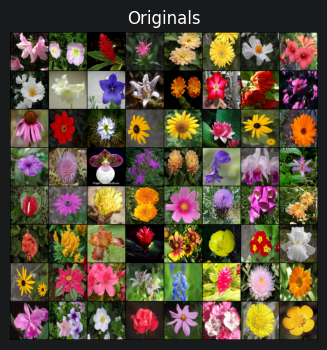

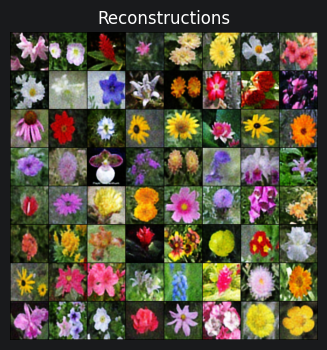

In [5]:
show(images, "Originals")
show(recon, "Reconstructions")

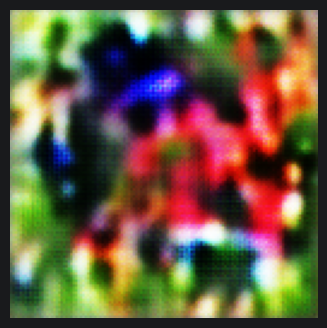

In [6]:
# decode a zero vector
z_zero = torch.rand(1, ae.latent_dim)

with torch.no_grad():
    img_zero = ae.decode(z_zero)

show(img_zero)